In [1]:
# STEP 1: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For splitting data
from sklearn.model_selection import train_test_split

# For scaling
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# For encoding categorical columns
from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
df = pd.read_csv("data.csv")
df.head()


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

In [7]:
df.describe()


,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,44.021700,2.527000,24.858800,3.989600,8.168382e+05
std,15.203998,1.713991,14.652622,2.010496,1.821089e+06
min,18.000000,0.000000,0.000000,1.000000,3.104400e+04
25%,31.000000,1.000000,12.000000,2.000000,6.844600e+04
50%,44.000000,3.000000,25.000000,4.000000,7.294300e+04
75%,57.000000,4.000000,37.000000,6.000000,3.506675e+05
max,70.000000,5.000000,50.000000,7.000000,9.992571e+06


In [9]:
df.shape


(10000, 14)

In [11]:
df.isnull().sum()


Age                               0
Education_Level                   0
Occupation                        0
Number_of_Dependents              0
Location                          0
Work_Experience                   0
Marital_Status                    0
Employment_Status                 0
Household_Size                    0
Homeownership_Status              0
Type_of_Housing                   0
Gender                            0
Primary_Mode_of_Transportation    0
Income                            0
dtype: int64

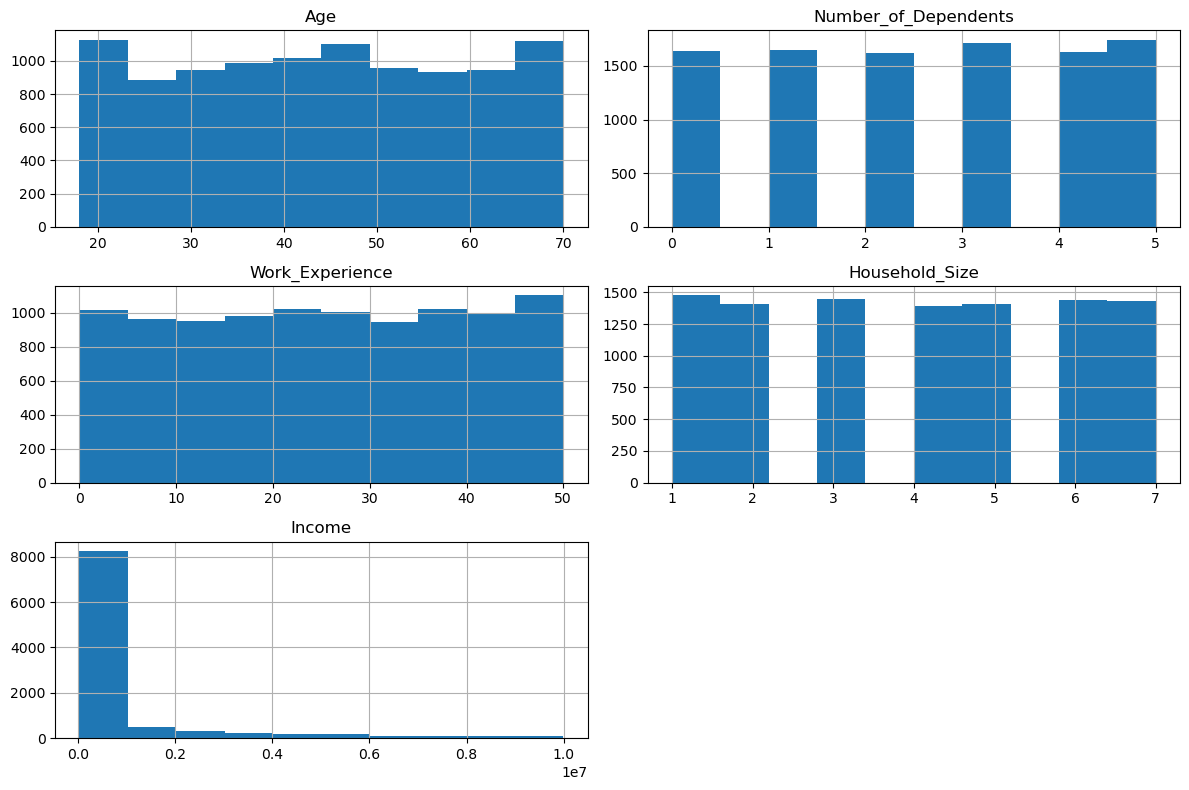

In [13]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


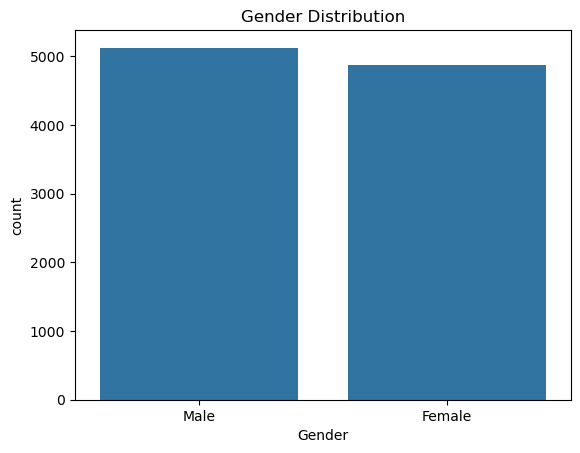

In [15]:
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()


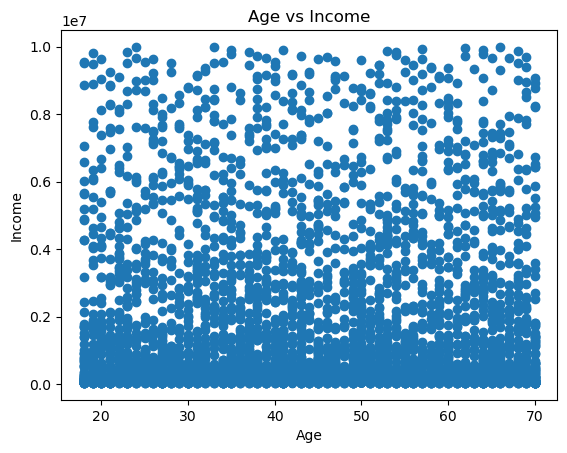

In [17]:
plt.scatter(df["Age"], df["Income"])
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income")
plt.show()

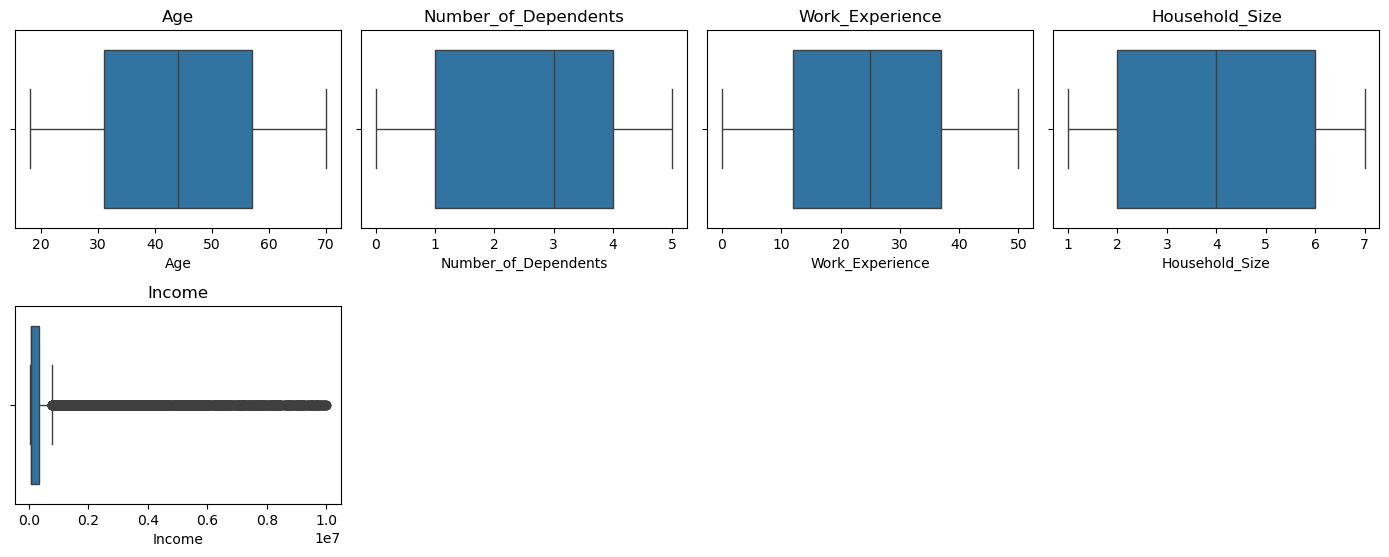

In [19]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [21]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"{col}: {len(outliers)} outliers")


Age: 0 outliers
Number_of_Dependents: 0 outliers
Work_Experience: 0 outliers
Household_Size: 0 outliers
Income: 1931 outliers


In [23]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop("Income")  # do NOT scale target


In [25]:
scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [27]:
df.head()


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,0.787878,Master's,Technology,1.442904,Urban,-0.263365,Married,Full-time,1.497416,Own,Apartment,Male,Public transit,72510
1,1.642959,High School,Finance,-1.474411,Urban,-1.423625,Single,Full-time,1.497416,Own,Apartment,Male,Biking,75462
2,0.130124,Bachelor's,Technology,-0.890948,Urban,-1.628377,Single,Full-time,1.497416,Own,Single-family home,Female,Car,71748
3,-0.790733,High School,Others,-0.307485,Urban,0.487391,Married,Full-time,-1.487070,Own,Apartment,Female,Car,74520
4,1.050980,Bachelor's,Finance,0.275978,Urban,-0.672869,Married,Self-employed,0.005173,Own,Townhouse,Male,Walking,640210


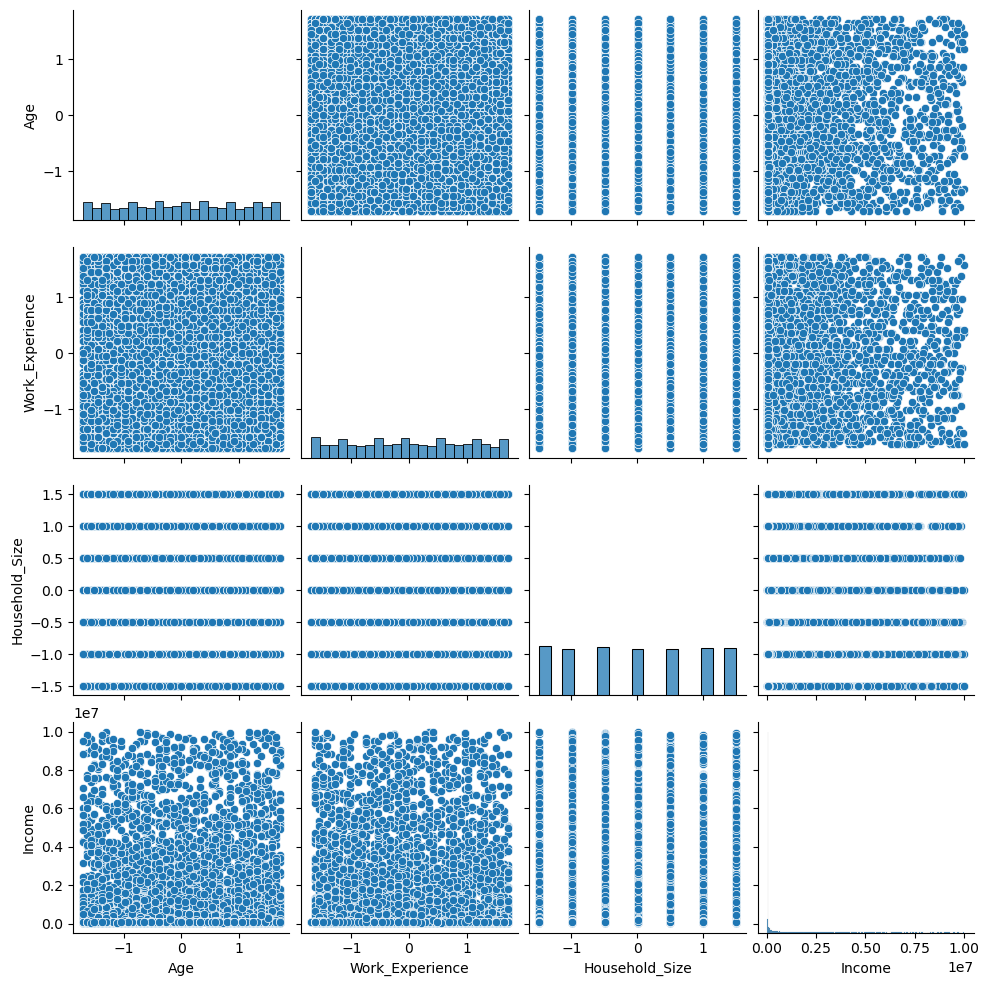

In [29]:
selected_cols = ["Age", "Work_Experience", "Household_Size", "Income"]

sns.pairplot(df[selected_cols])
plt.show()


In [31]:
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()
corr_matrix


,Age,Number_of_Dependents,Work_Experience,Household_Size,Income
Age,1.000000,0.001181,0.000310,0.010565,0.008739
Number_of_Dependents,0.001181,1.000000,-0.000708,-0.006419,0.011413
Work_Experience,0.000310,-0.000708,1.000000,0.006007,-0.027541
Household_Size,0.010565,-0.006419,0.006007,1.000000,-0.011356
Income,0.008739,0.011413,-0.027541,-0.011356,1.000000


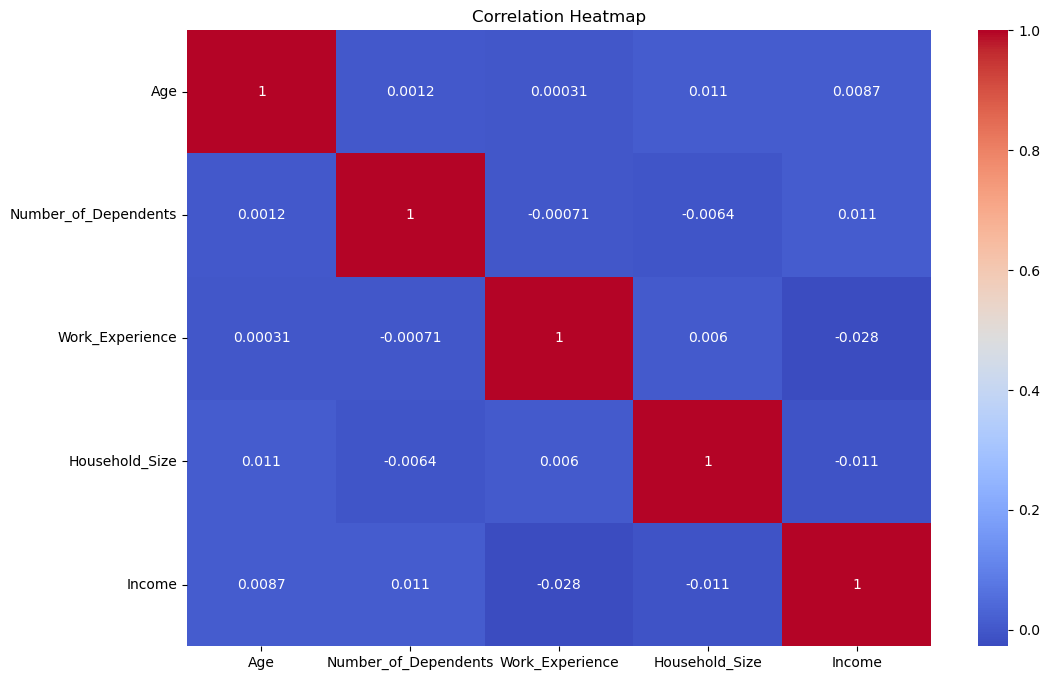

In [33]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [35]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols


Index(['Education_Level', 'Occupation', 'Location', 'Marital_Status',
       'Employment_Status', 'Homeownership_Status', 'Type_of_Housing',
       'Gender', 'Primary_Mode_of_Transportation'],
      dtype='object')

In [37]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [39]:
X = df.drop("Income", axis=1)
y = df["Income"]


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [43]:
lin_reg = LinearRegression()


In [45]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)


In [47]:
lin_reg.fit(X_train, y_train)


LinearRegression()

In [49]:
# Transform train and test sets for polynomial regression
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Train the polynomial regression model
poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)


LinearRegression()

In [51]:
y_pred_lin = lin_reg.predict(X_test)


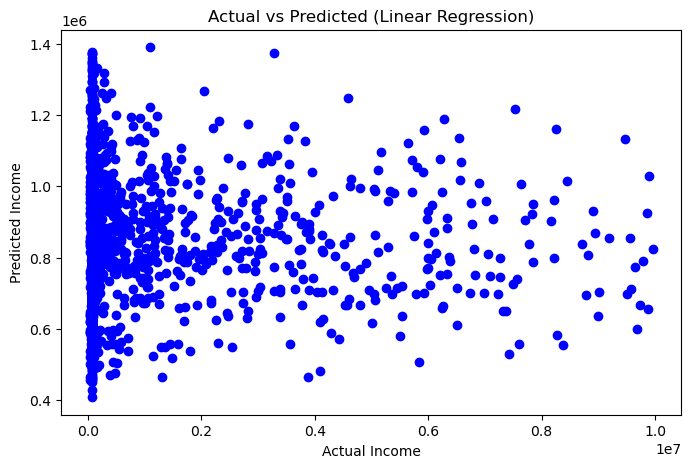

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lin, color="blue")
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


In [55]:
y_pred_poly = poly_reg.predict(X_poly_test)


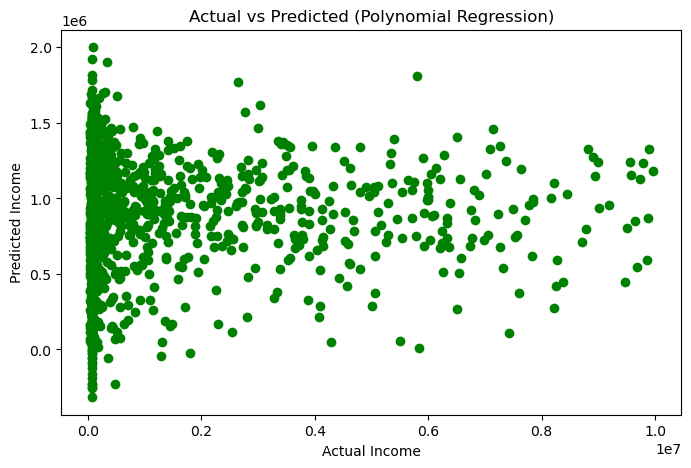

In [57]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_poly, color="green")
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.show()


In [59]:
mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)


In [61]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)


In [63]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MSE": [mse_lin, mse_poly],
    "MAE": [mae_lin, mae_poly],
    "RMSE": [rmse_lin, rmse_poly],
    "R2 Score": [r2_lin, r2_poly]
})

comparison


,Model,MSE,MAE,RMSE,R2 Score
0,Linear Regression,3.146274e+12,1.105081e+06,1.773774e+06,0.002722
1,Polynomial Regression,3.152052e+12,1.100216e+06,1.775402e+06,0.000891


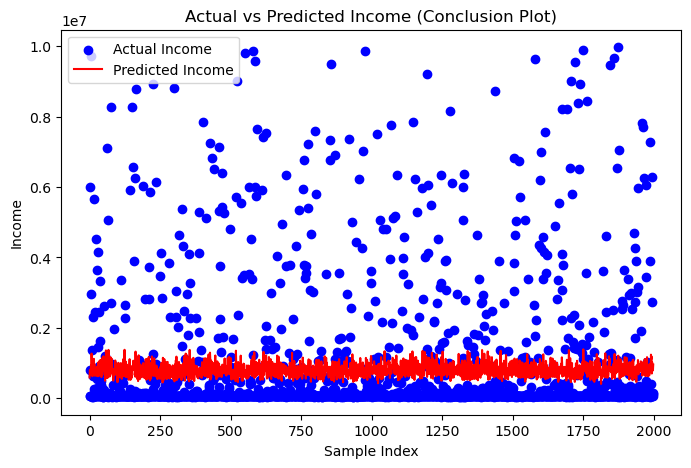

In [65]:
plt.figure(figsize=(8,5))

# Actual values as scatter
plt.scatter(range(len(y_test)), y_test, color='blue', label="Actual Income")

# Predicted values as line
plt.plot(range(len(y_pred_lin)), y_pred_lin, color='red', label="Predicted Income")

plt.xlabel("Sample Index")
plt.ylabel("Income")
plt.title("Actual vs Predicted Income (Conclusion Plot)")
plt.legend()
plt.show()
